# Exploring the FPbase fluorescent-protein dataset

Basic visual summaries of the proteins extracted from [FPbase](https://www.fpbase.org).

Each section answers one question:
1. Oligomerization — how many are monomers vs. other states
2. Excitation / emission maximum distributions
3. How excitation and emission maxima correlate
4. How many proteins have ex_max, em_max, or both recorded
5. Brightness distribution

> **Note:** spectral and brightness values are stored *per state* in FPbase
> (a protein can have several). Here each protein is represented by its **first
> (default) state**, giving one row per protein.

In [1]:
import json
import os

import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Load the export if present, otherwise fetch live via the library.
CANDIDATES = [
    "data/fpbase_proteins.json",
    "fpbase_output/fpbase_proteins.json",
    "../data/fpbase_proteins.json",
]
path = next((p for p in CANDIDATES if os.path.exists(p)), None)
if path:
    with open(path) as fh:
        proteins = json.load(fh)
    print(f"Loaded {len(proteins)} proteins from {path}")
else:
    from fpbase_extractor import fetch_proteins, normalize_all
    raw, src = fetch_proteins(source="auto")
    proteins = normalize_all(raw)
    print(f"Fetched {len(proteins)} proteins live from FPbase ({src})")

Loaded 1041 proteins from fpbase_output/fpbase_proteins.json


In [2]:
def first_state(p):
    """Representative state for a protein (FPbase lists the default first)."""
    states = p.get("states") or []
    return states[0] if states else {}

rows = []
for p in proteins:
    s = first_state(p)
    rows.append({
        "name": p.get("name"),
        "oligomerization": (p.get("oligomerization") or "unknown") or "unknown",
        "switch_type": p.get("switch_type_label") or "unknown",
        "ext_coeff": s.get("ext_coeff"),
        "qy": s.get("qy"),
        "ex_max": s.get("ex_max"),
        "em_max": s.get("em_max"),
        "brightness": s.get("brightness"),
    })

df = pd.DataFrame(rows)
print(f"{len(df)} proteins")
df.head()

1041 proteins


,name,oligomerization,switch_type,ext_coeff,qy,ex_max,em_max,brightness
0,10B,unknown,unknown,30800.0,NaN,513.0,525.0,NaN
1,11,unknown,basic,33000.0,NaN,502.0,512.0,NaN
2,22G,tetramer,unknown,NaN,NaN,NaN,NaN,NaN
3,(3-F)Tyr-EGFP,unknown,basic,NaN,NaN,484.0,514.0,NaN
4,5B,unknown,unknown,19400.0,NaN,512.0,524.0,NaN


## 1. Oligomerization — monomer vs. other states

oligomerization
monomer         411
unknown         350
tetramer        119
dimer           114
weak dimer       32
tandem dimer     15

Monomer: 411 (39.5%)
Other / non-monomer: 630 (60.5%)


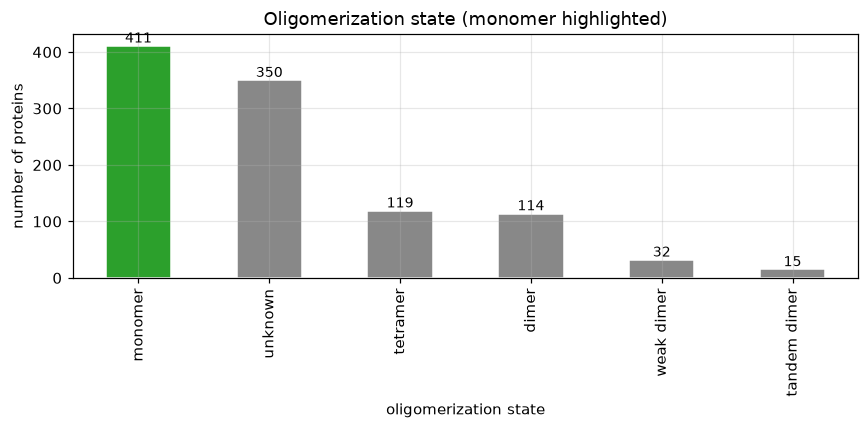

In [3]:
counts = df["oligomerization"].value_counts()
print(counts.to_string())

n = len(df)
mono = int((df["oligomerization"] == "monomer").sum())
print(f"\nMonomer: {mono} ({mono / n * 100:.1f}%)")
print(f"Other / non-monomer: {n - mono} ({(n - mono) / n * 100:.1f}%)")

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#2ca02c" if k == "monomer" else "#888" for k in counts.index]
counts.plot.bar(ax=ax, color=colors, edgecolor="white")
ax.set_ylabel("number of proteins")
ax.set_xlabel("oligomerization state")
ax.set_title("Oligomerization state (monomer highlighted)")
for i, v in enumerate(counts.values):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## 2. Excitation and emission maximum distributions

ex_max:
count    921.0
mean     509.7
std       66.2
min      300.0
25%      476.0
50%      502.0
75%      560.0
max      702.0

em_max:
count     877.0
mean      542.1
std        63.5
min       300.0
25%       505.0
50%       515.0
75%       592.0
max      1000.0


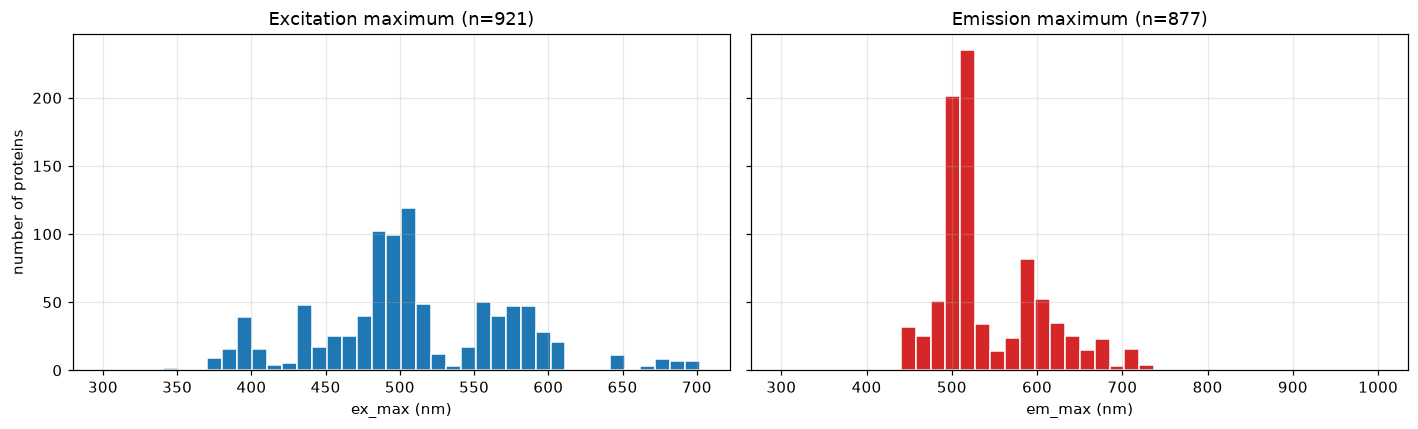

In [4]:
ex = df["ex_max"].dropna()
em = df["em_max"].dropna()

print("ex_max:")
print(ex.describe().round(1).to_string())
print("\nem_max:")
print(em.describe().round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
axes[0].hist(ex, bins=40, color="#1f77b4", edgecolor="white")
axes[0].set_title(f"Excitation maximum (n={len(ex)})")
axes[0].set_xlabel("ex_max (nm)")
axes[0].set_ylabel("number of proteins")
axes[1].hist(em, bins=40, color="#d62728", edgecolor="white")
axes[1].set_title(f"Emission maximum (n={len(em)})")
axes[1].set_xlabel("em_max (nm)")
plt.tight_layout()
plt.show()

## 3. Correlation between excitation and emission maxima

Pearson r (ex_max vs em_max) = 0.846   over 877 proteins

Stokes shift (em - ex), nm:
count    877.0
mean      35.7
std       36.0
min      -42.0
25%       14.0
50%       25.0
75%       42.0
max      515.0


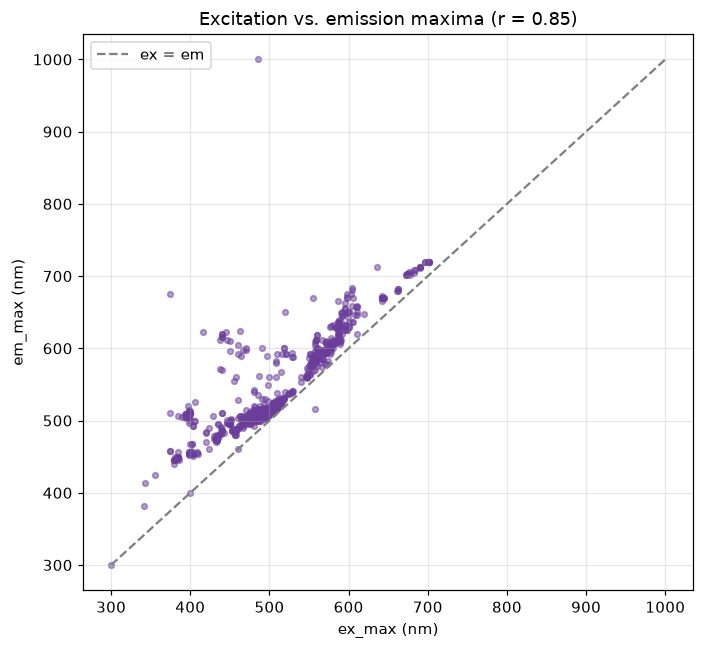

In [5]:
sub = df.dropna(subset=["ex_max", "em_max"])
r = sub["ex_max"].corr(sub["em_max"])
stokes = (sub["em_max"] - sub["ex_max"])
print(f"Pearson r (ex_max vs em_max) = {r:.3f}   over {len(sub)} proteins")
print(f"\nStokes shift (em - ex), nm:")
print(stokes.describe().round(1).to_string())

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(sub["ex_max"], sub["em_max"], s=14, alpha=0.5, color="#6a3d9a")
lo = min(sub["ex_max"].min(), sub["em_max"].min())
hi = max(sub["ex_max"].max(), sub["em_max"].max())
ax.plot([lo, hi], [lo, hi], "--", color="gray", label="ex = em")
ax.set_xlabel("ex_max (nm)")
ax.set_ylabel("em_max (nm)")
ax.set_title(f"Excitation vs. emission maxima (r = {r:.2f})")
ax.legend()
plt.tight_layout()
plt.show()

## 4. How many proteins have ex_max, em_max, or both recorded

ex_max recorded:        921
em_max recorded:        877
both recorded:          877
ex only:                44
em only:                0
neither:                120
total proteins:         1041


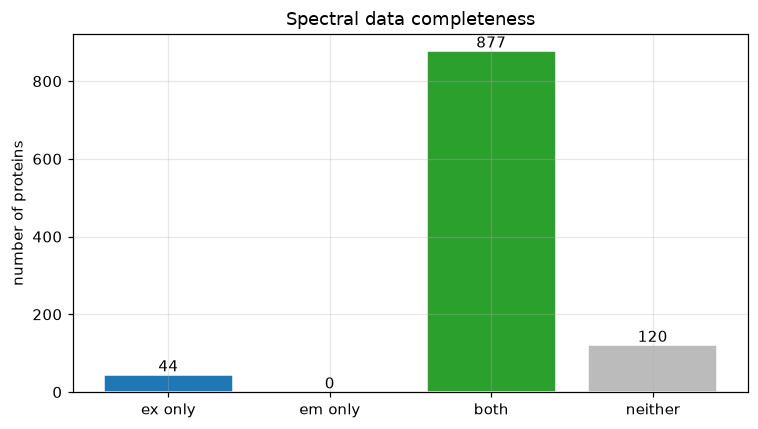

In [6]:
has_ex = df["ex_max"].notna()
has_em = df["em_max"].notna()

ex_only = int((has_ex & ~has_em).sum())
em_only = int((has_em & ~has_ex).sum())
both = int((has_ex & has_em).sum())
neither = int((~has_ex & ~has_em).sum())

print(f"ex_max recorded:        {int(has_ex.sum())}")
print(f"em_max recorded:        {int(has_em.sum())}")
print(f"both recorded:          {both}")
print(f"ex only:                {ex_only}")
print(f"em only:                {em_only}")
print(f"neither:                {neither}")
print(f"total proteins:         {len(df)}")

cats = ["ex only", "em only", "both", "neither"]
vals = [ex_only, em_only, both, neither]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(cats, vals, color=["#1f77b4", "#d62728", "#2ca02c", "#bbb"], edgecolor="white")
ax.set_ylabel("number of proteins")
ax.set_title("Spectral data completeness")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, str(v), ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 5. Brightness distribution

Brightness = extinction coefficient x quantum yield / 1000. It is strongly
right-skewed, so a log-scaled x-axis is shown alongside the linear histogram.

brightness recorded for 629 proteins
count    629.00
mean      31.90
std       30.72
min        0.01
25%        8.27
50%       22.88
75%       48.75
max      164.90


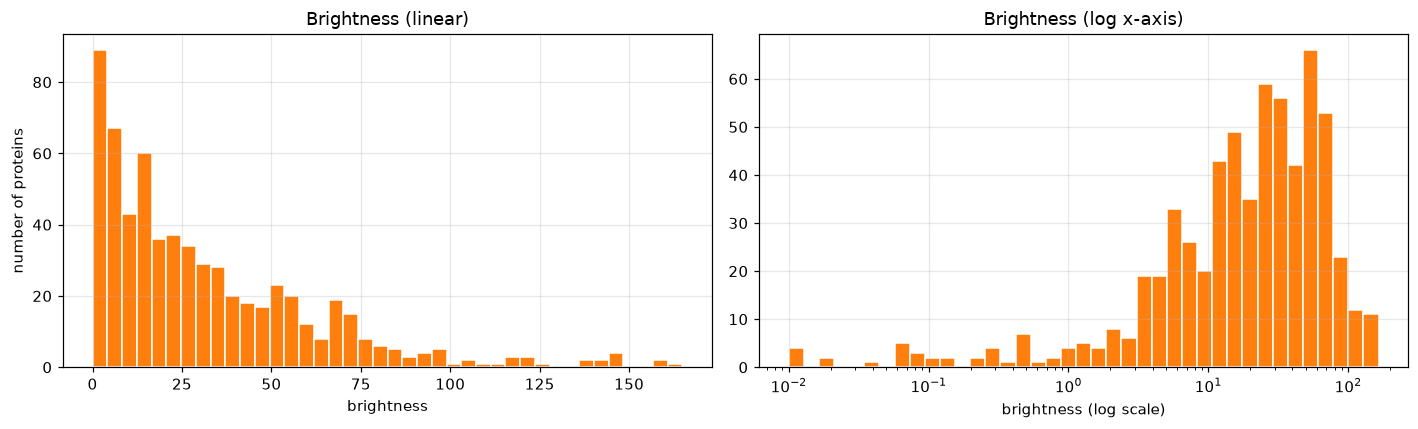

In [7]:
b = df["brightness"].dropna()
b = b[b > 0]
print(f"brightness recorded for {len(b)} proteins")
print(b.describe().round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(b, bins=40, color="#ff7f0e", edgecolor="white")
axes[0].set_title("Brightness (linear)")
axes[0].set_xlabel("brightness")
axes[0].set_ylabel("number of proteins")

import numpy as np
axes[1].hist(b, bins=np.logspace(np.log10(b.min()), np.log10(b.max()), 40),
             color="#ff7f0e", edgecolor="white")
axes[1].set_xscale("log")
axes[1].set_title("Brightness (log x-axis)")
axes[1].set_xlabel("brightness (log scale)")
plt.tight_layout()
plt.show()

## 6. Are quantum yield, extinction coefficient, and brightness correlated?

FPbase defines **brightness = extinction coefficient x quantum yield / 1000**,
so the final plot (brightness vs. `qy * ext_coeff / 1000`) should fall on the
identity line `y = x` — a consistency check on the data. The correlation matrix
and the two scatters show how each input relates to brightness on its own.

628 proteins have qy, ext_coeff and brightness all recorded

Pearson correlation matrix:
               qy  ext_coeff  brightness
qy          1.000      0.103       0.709
ext_coeff   0.103      1.000       0.669
brightness  0.709      0.669       1.000


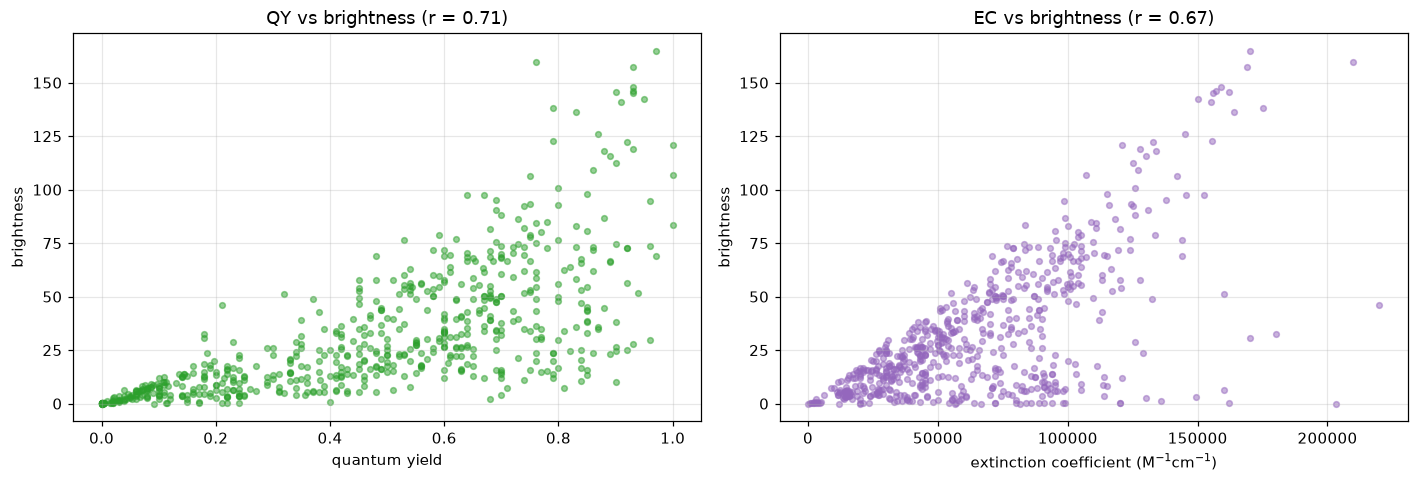

In [8]:
sub = df.dropna(subset=["qy", "ext_coeff", "brightness"])
sub = sub[(sub["qy"] > 0) & (sub["ext_coeff"] > 0) & (sub["brightness"] > 0)]
print(f"{len(sub)} proteins have qy, ext_coeff and brightness all recorded")

corr = sub[["qy", "ext_coeff", "brightness"]].corr()
print("\nPearson correlation matrix:")
print(corr.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(sub["qy"], sub["brightness"], s=14, alpha=0.5, color="#2ca02c")
axes[0].set_xlabel("quantum yield")
axes[0].set_ylabel("brightness")
axes[0].set_title(f"QY vs brightness (r = {sub['qy'].corr(sub['brightness']):.2f})")

axes[1].scatter(sub["ext_coeff"], sub["brightness"], s=14, alpha=0.5, color="#9467bd")
axes[1].set_xlabel("extinction coefficient (M$^{-1}$cm$^{-1}$)")
axes[1].set_ylabel("brightness")
axes[1].set_title(f"EC vs brightness (r = {sub['ext_coeff'].corr(sub['brightness']):.2f})")
plt.tight_layout()
plt.show()

r(computed, brightness) = 1.0000
max |brightness - qy*EC/1000| = 0.005
median |difference|          = 0.0000


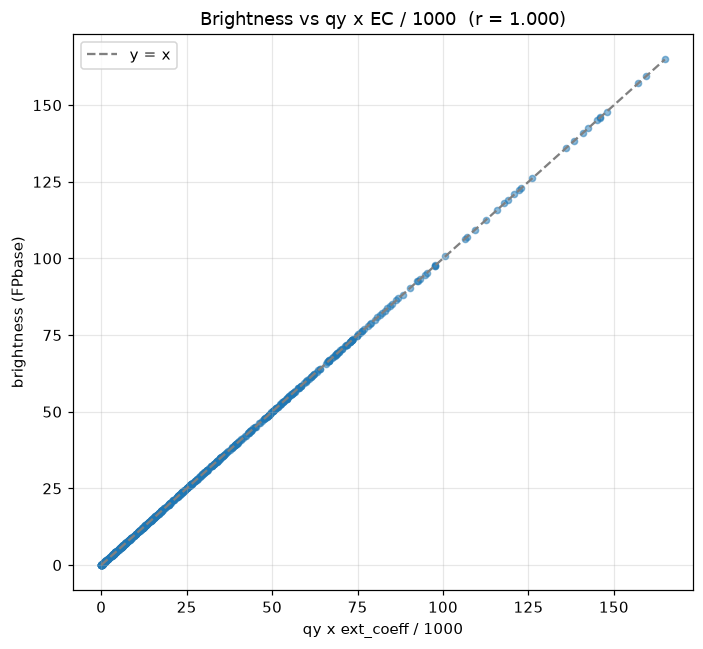

In [9]:
# Requested plot: y = brightness  vs  x = qy * ext_coeff / 1000
computed = sub["qy"] * sub["ext_coeff"] / 1000
r = computed.corr(sub["brightness"])
resid = (sub["brightness"] - computed).abs()
print(f"r(computed, brightness) = {r:.4f}")
print(f"max |brightness - qy*EC/1000| = {resid.max():.3f}")
print(f"median |difference|          = {resid.median():.4f}")

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(computed, sub["brightness"], s=16, alpha=0.5, color="#1f77b4")
lo = min(computed.min(), sub["brightness"].min())
hi = max(computed.max(), sub["brightness"].max())
ax.plot([lo, hi], [lo, hi], "--", color="gray", label="y = x")
ax.set_xlabel("qy x ext_coeff / 1000")
ax.set_ylabel("brightness (FPbase)")
ax.set_title(f"Brightness vs qy x EC / 1000  (r = {r:.3f})")
ax.legend()
plt.tight_layout()
plt.show()